In [ ]:
# ============================================================
# 악기 오디오 파일 분류 실습 
# ============================================================
# 데이터 구조:
#   ./audio/
#       cello/
#           *.mp3
#       flute/
#           *.mp3
#       oboe/
#           *.mp3
#       sax/
#           *.mp3
#       trumpet/
#           *.mp3
#       viola/
#           *.mp3
# 실습 목표:
#   1) 오디오 파일 읽기
#   2) waveplot 시각화
#   3) FFT 시각화
#   4) Spectrogram 생성 및 이미지 저장
#   5) CNN 분류 모델 학습
#   6) 성능 평가
#   7) 신규 오디오 예측 (절대경로 입력)
#   8) 예측 결과 시각화
#   9) 에러 방지 로직 반영

In [4]:
# ----------------------------------------------------------------
# 1. 라이브러리 import
# ----------------------------------------------------------------

import os
import glob
import random
import shutil  # 폴더 삭제, 생성 등 파일 시스템 작업에 사용

# 데이터 처리 및 시각화 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 오디오 라이브러리
import librosa
import librosa.display

# 이미지 처리 라이브러리
from PIL import Image

# 분석 라이브러리
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)



In [23]:
# ------------------------------------------------------------
# 2. 기본 경로 및 전역 하이퍼파라미터 설정
# ------------------------------------------------------------

BASE_DIR = os.getcwd()                                                 # root dir 설정
AUDIO_DIR = os.path.join(BASE_DIR, "audio")                            # 오디오 파일이 저장된 루트 폴더

SPEC_DIR = os.path.join(BASE_DIR, "spectrogram_data")                  # 오디오를 이미지로 변환하여 저장할 루드 디렉토리
SPLIT_DIR = os.path.join(BASE_DIR, "spectrogram_split")                # ai 학습용으로 train/test/val 구조로 저장할 폴더

BEST_MODEL_PATH = os.path.join(BASE_DIR, "best_instrument_cnn_model.keras")   # 최종 학습 모델 결과 저장 파일
TEMP_PREDICT_IMAGE_PATH = os.path.join(BASE_DIR, "temp_predict_spectrogram.png")  # 신규 예측시 임시로 스펙트로그램 이미지를 저장할 경로

CLASSES = ['cello', 'flute', 'oboe', 'sax', 'trumpet', 'viola']    # 분류 대상 클래스  <-- 폴더명과 일치하도록 정의

# CNN 입력 이미지 높이
IMG_HEIGHT = 224

# CNN 입력 이미지 너비
IMG_WIDTH = 224

# signal processing 파라미터 설정
SR = 44100                                          # 샘플링 주파수
DURATION = 1.5                                      # 오디오 길이(초단위)
SAMPLES_PER_TRACK = SR * DURATION                   # 1개 오디오 샘플당 기대되는 총 샘플 수
N_FFT = 4096                                        # 멜 스펙트로그램 생성 시, 사용할 FFT 윈도우 길이
HOP_LENGTH = 512                                   # 프레임 간 HOP 크기 (값이 작을수록 시간 해상도 증가) 
N_MELS = 126                                        # MEL Filter bank (너무 작으면 정보 깨지고, 너무 크면 이미지 복잡해짐)

BATCH_SIZE = 16                                     # 학습 미니배치 크기
EPOCHS = 20                                         # 반복 학습 수


In [9]:
# ------------------------------------------------------------
# 3. 유효성 검사 및 공통 유틸리티 함수
# ------------------------------------------------------------

def ensure_directory_exists(dir_path):
    '''
    지정한 디렉토리가 존재하지 않으면 생성
    '''
    os.makedirs(dir_path, exist_ok=True)

def validate_audio_directory_structure(audio_dir, classes):
    '''
    audio 폴더와 클래스별 하위 폴더가 존재하는지 확인
    '''
    if not os.path.exists(audio_dir):
        raise FileNotFoundError(f"[오류] audio 루트 폴더를 찾을 수 없습니다: {audio_dir}")

    for cls in classes:
        class_dir = os.path.join(audio_dir, cls)
        if not os.path.exists(class_dir):
            raise FileNotFoundError(f"[오류] 클래스 폴더가 없습니다 : {class_dir}")


def count_audio_files(audio_dir, classes, extension="*.mp3"):
    '''
    클래스 별 오디오 파일 개수를 집계하여 dict 형태로 변환
    '''
    counts = {}
    for cls in classes:
        pattern = os.path.join(audio_dir, cls, extension)
        counts[cls] = len(glob.glob(pattern))
    return counts

def validate_minimum_files_per_class(file_counts, minimum_count=3):
    '''
    각 클래스에 최소 개수 이상의 파일이 존재하는지 검증
    '''
    for cls, count in file_counts.items():
        if count < minimum_count:
            raise ValueError(
                f"[오류] 클래스 '{cls}'의 파일 수가 너무 적습니다."
                f"최소 {minimum_count}개 이상 필요하지만 현재 {count}개입니다."
            )

def safe_remove_path(path):
    '''
    파일 또는 디렉토리가 존재할 때만 삭제
    '''
    if os.path.isdir(path):
        shutil.rmtree(path)
    elif os.path.isfile(path):
        os.remove(path)

def print_section_title(title):
    '''
    노트북에서 섹션 구분이 명확하게 보이도록 제목 출력
    '''
    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)    



데이터 폴더 및 파일 개수 확인
원본 오디오 루트 경로: C:\Users\human\Desktop\workspace\11차 실습\DL\sound\audio
스펙트로그램 저장 경로: C:\Users\human\Desktop\workspace\11차 실습\DL\sound\spectrogram_data
분할 데이터 저장 경로: C:\Users\human\Desktop\workspace\11차 실습\DL\sound\spectrogram_split
     Class  Count
0    cello    100
1    flute    100
2     oboe    100
3      sax    100
4  trumpet    100
5    viola    100


<function matplotlib.pyplot.show(close=None, block=None)>

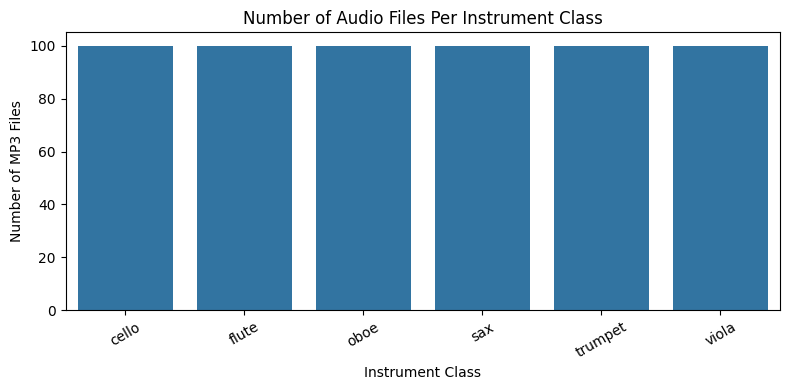

In [10]:
# ------------------------------------------------------------
# 데이터 폴더 구조 및 파일 개수 확인
# ------------------------------------------------------------
# audio 폴더와 클래스별 하위 폴더가 실제로 존재하는지 검증
validate_audio_directory_structure(AUDIO_DIR, CLASSES)

# 클래스 별 MP3 개수 집계
file_counts = count_audio_files(AUDIO_DIR, CLASSES, extension='*.mp3')

# 각 클래스가 최소한의 샘플 수를 갖는지 확인
validate_minimum_files_per_class(file_counts, minimum_count=3)

# 집계 결과를 데이터프레임으로 변환
file_count_df = pd.DataFrame(list(file_counts.items()), columns=["Class", "Count"])

# 현재 데이터 구성 상황을 출력
print_section_title("데이터 폴더 및 파일 개수 확인")
print("원본 오디오 루트 경로:", AUDIO_DIR)
print("스펙트로그램 저장 경로:", SPEC_DIR)
print("분할 데이터 저장 경로:", SPLIT_DIR)
print(file_count_df)

#클래스별 데이터 불균형 여부를 시각화하여 확인
plt.figure(figsize=(8,4))
sns.barplot(data=file_count_df, x= "Class", y= "Count")
plt.title("Number of Audio Files Per Instrument Class")
plt.xlabel("Instrument Class")
plt.ylabel("Number of MP3 Files")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show


In [13]:
# ------------------------------------------------------------
# 5. 오디오 로드 함수 정의
# ------------------------------------------------------------

def load_audio_file(file_path, sr=SR, duration=DURATION):
    """
    오디오 파일을 모노 신호로 읽고, 지정 길이로 고정
     - 모델 입력 일관성을 위해 모든 오디오 길이를 동일하게 맞춘다
     - 너무 짧은 파일은 zero-padding 한다
     - 너무 긴 파일은 앞부분을 사용한다
    """
    # 입력 경로가 문자열인지 확인
    if not isinstance(file_path, str):
        raise TypeError(f"[오류] file_path는 문자열이어야 합니다. 현재 타입: {type(file_path)}")

    # 실제 파일 존재 여부 확인
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"[오류] 오디오 파일이 존재하지 않습니다: {file_path}")

    # 파일 확장자 확인
    valid_exts = [".mp3", ".wav", ".flac", ".ogg", ".m4a"]
    ext = os.path.splitext(file_path)[1].lower()
    if ext not in valid_exts:
        raise ValueError(f"[오류] 지원하지 않는 오디오 확장자입니다: {ext}")

    try:
        y, sr = librosa.load(file_path, sr=sr, mono=True)
    except Exception as e:
        raise RuntimeError(f"[오류] 오디오 로드 실패: {file_path}\n원인: {e}")

    # 비어 있는 배열이 들어오면 이후 FFT/STFT에서 실패하므로 사전 차단
    if y is None or len(y) == 0:
        raise ValueError(f"[오류] 오디오 데이터가 비어 있습니다: {file_path}")

    # 목표 샘플 길이 계산
    target_length = int(sr * duration)

    # 길이가 짧으면 뒤를 0으로 패딩하여 고정 길이를 맞춘다
    if len(y) < target_length:
        pad_width = target_length - len(y)
        y = np.pad(y, (0, pad_width), mode='constant')

    # 길이가 길면 앞부분만 사용
    else:
        y = y[:target_length]

    return y, sr



In [14]:
# ------------------------------------------------------------
# 6. 샘플 오디오 파일 1개 선택 및 기본 분석
# ------------------------------------------------------------

# 데이터 시각화 예제로 사용할 첫 번째 샘플 분석
sample_file = None
sample_class = None

for cls in CLASSES:
    pattern = os.path.join(AUDIO_DIR, cls, "*.mp3")
    files = glob.glob(pattern)
    if len(files) > 0:
        sample_file = files[0]
        sample_class = cls
        break

# 샘플 파일을 하나도 찾지 못한 경우 즉시 에러 발생
if sample_file is None:
    raise FileNotFoundError("[오류] 샘플로 사용할 mp3 파일을 찾지 못했습니다.")

# 샘플 파일 로드
y_sample, sr_sample = load_audio_file(sample_file)

# 샘플 파일 정보 출력
print("샘플 클래스: ", sample_class)
print("샘플 파일: ", sample_file)
print("샘플링 주파수: ", sr_sample)
print("총 샘플 수: ", len(y_sample))
print("총 길이(초): ", len(y_sample) / sr_sample)


샘플 클래스:  cello
샘플 파일:  C:\Users\human\Desktop\workspace\11차 실습\DL\sound\audio\cello\cello_A2_025_forte_arco-normal.mp3
샘플링 주파수:  44100
총 샘플 수:  66150
총 길이(초):  1.5


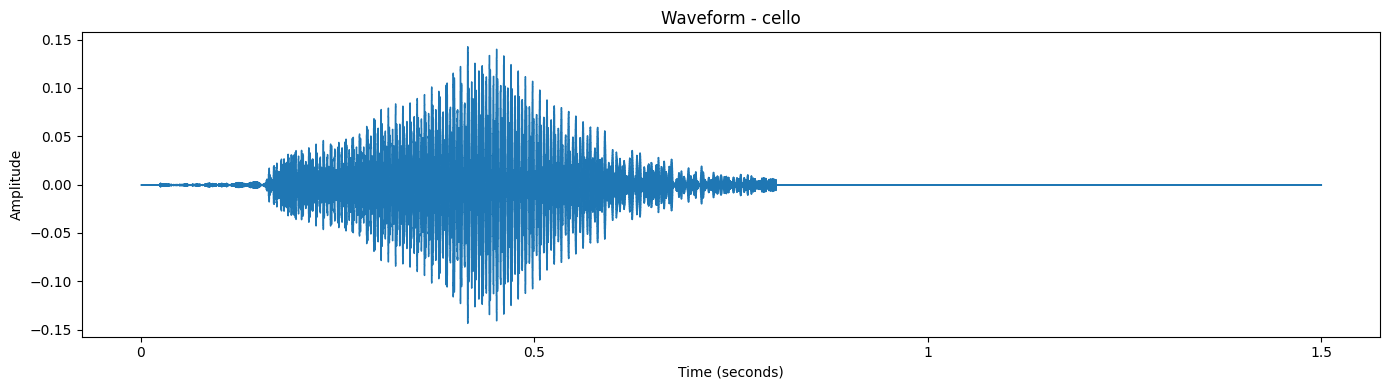

In [16]:
# ------------------------------------------------------------
# 7. 샘플 오디오 waveplot 시각화
# ------------------------------------------------------------

# wave 파형은 시간축에서 신호 진폭이 어떻게 변하는지 보여줌 (dB)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y_sample, sr=sr_sample)
plt.title(f"Waveform - {sample_class}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


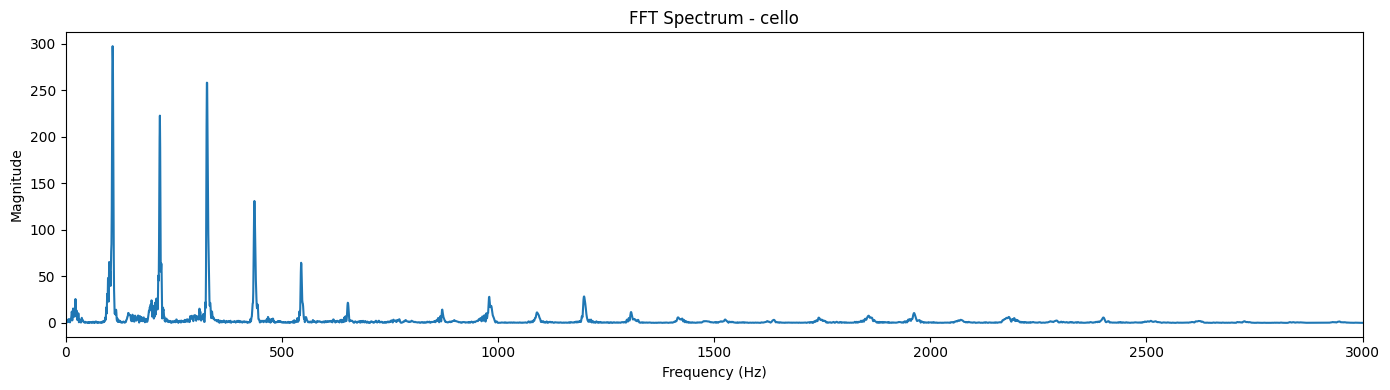

In [18]:
# ------------------------------------------------------------
# 8. 샘플 오디오 FFT 시각화 (주파수 데이터로 변환)
# ------------------------------------------------------------

# FFT : 시간영역 신호를 주파수영역으로 변환하여 어떤 주파수 성분이 강한지 확인
fft_sample = np.fft.fft(y_sample)

# 복소수 푸리에 계수의 절대값을 취해서 magnitude spectrum을 계산
magnitude_sample = np.abs(fft_sample)

# 각 인덱스가 실제 어떤 주파수에 대응하는지 계산
freqs_sample = np.fft.fftfreq(len(magnitude_sample), d=1 / sr_sample)

# 실수 신호 fft가 음수 주파수 구간이 대칭이므로 양수 영역만 사용
positive_freqs_sample = freqs_sample[:len(freqs_sample) // 2]
positive_magnitude_sample = magnitude_sample[:len(magnitude_sample) // 2]

# fft 시각화
plt.figure(figsize=(14,4))
plt.plot(positive_freqs_sample, positive_magnitude_sample)
plt.title(f"FFT Spectrum - {sample_class}")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 3000)
plt.tight_layout()
plt.show()


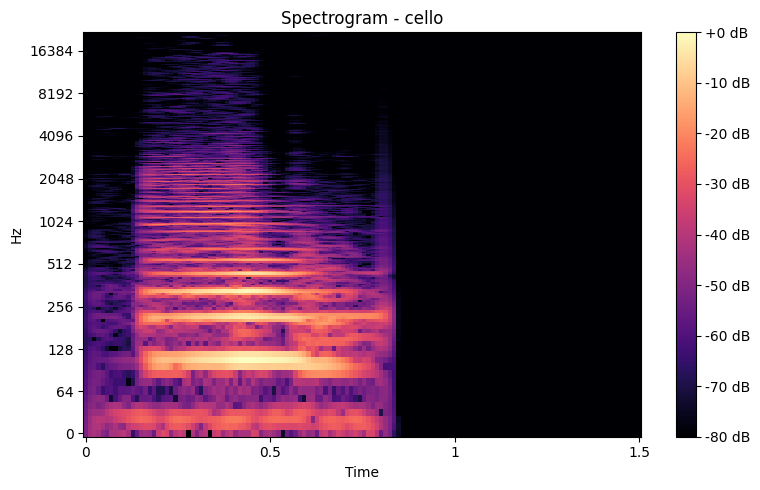

In [22]:
# ------------------------------------------------------------
# 9. 샘플 오디오 STFT Spectrogram 시각화
# ------------------------------------------------------------
SR = 44100                                          # 샘플링 주파수
DURATION = 1.5                                      # 오디오 길이(초단위)
SAMPLES_PER_TRACK = SR * DURATION                   # 1개 오디오 샘플당 기대되는 총 샘플 수
N_FFT = 4096                                        # 멜 스펙트로그램 생성 시, 사용할 FFT 윈도우 길이
HOP_LENGTH = 512                                   # 프레임 간 HOP 크기 (값이 작을수록 시간 해상도 증가) 
N_MELS = 126 


# STFT : 짧은 시간 구간별로 FFT를 수행하여 시간-주파수 2차원으로 시그널 표현
stft_sample = librosa.stft(y_sample, n_fft=N_FFT, hop_length=HOP_LENGTH)

# 복소수 stft 결과의 절대값을 취하여 magnitude spectrogram 생성
spectrogram_sample = np.abs(stft_sample)

# 사람의 청각 및 신호 에너지 해석에 유리하도록 dB 스케일로 변환
spectrogram_db_sample = librosa.amplitude_to_db(spectrogram_sample, ref=np.max)

# 로그 주파수축 Spectrogram 그리기
plt.figure(figsize=(8,5))
librosa.display.specshow(
    spectrogram_db_sample,
    sr=sr_sample,
    hop_length=HOP_LENGTH,
    x_axis='time',
    y_axis='log',
    cmap='magma'
)
plt.colorbar(format='%+2.0f dB')
plt.title(f"Spectrogram - {sample_class}")
plt.tight_layout()
plt.show()


In [24]:
# ------------------------------------------------------------
# 10. 오디오 파일에 대해 Spectrogram 이미지 저장하는 함수
# ------------------------------------------------------------
def save_spectrogram_image(audio_path, save_path, sr=SR, duration= DURATION):
    # 저장 경로의 상위 폴더가 존재하도록 보장
    save_dir = os.path.dirname(save_path)

    # save_path가 현재 작업 디렉토리 바로 아래 파일일 경우 dirname이 빈 문자열일 수 있음
    if save_dir != "":
        ensure_directory_exists(save_dir)

    # 오디오 로드
    y, sr = load_audio_file(audio_path, sr=sr, duration=duration)

    # melspectrogram 계산
    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        power=2.0
    )

    # power spectrogram을 dB로 변환
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    fig = plt.figure(figsize=(4,4))

    # 축/눈금 없이 스펙트러 패턴만 저장되도록 그리기
    librosa.display.specshow(
        mel_spec_db,
        sr=sr,
        hop_length=HOP_LENGTH,
        x_axis=None,
        y_axis=None,
        cmap='magma'
    )
    
    # cnn이 의미 없는 축 텍스트를 학습하지 않도록 축 제거
    plt.axis('off')

    # 저장 시 여백 최소화
    plt.tight_layout(pad=0)

    # png로 저장
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0)

    # 메모리 정리를 위해 figure를 닫는다
    plt.close(fig)

    # 저장된 이미지를 열어 rgb로 변환 후 입력 크기로 통일
    img = Image.open(save_path).convert("RGB")
    img = img.resize((IMG_WIDTH, IMG_HEIGHT))
    img.save(save_path)
    

In [25]:
# ------------------------------------------------------------
# 11. 전체 오디오 파일 --> Spectrogram 이미지 생성
# ------------------------------------------------------------

# 이전 실행 결과가 남아 있으면 삭제
safe_remove_path(SPEC_DIR)

# Spectrogram 루트폴더 생성
ensure_directory_exists(SPEC_DIR)   # spectrogram_data 폴더
print_section_title("스펙트로그램 이미지 생성 시작")

# 클래스별로 모든 mp3 파일을 순회하면서 spectrogram 이미지를 생성
for cls in CLASSES:
    class_audio_dir = os.path.join(AUDIO_DIR, cls)
    class_spec_dir = os.path.join(SPEC_DIR, cls)

    #클래스 별 spectrogram 저장 폴더 생성
    ensure_directory_exists(class_spec_dir)

    # 해당 클래스의 mp3 목록 가져오기
    audio_files = glob.glob(os.path.join(class_audio_dir, "*.mp3"))

    # 처리 현황 출력
    print(f"{cls}: {len(audio_files)}개 파일 처리 중....")

    # 각 파일을 spectrogram으로 변환
    for audio_file in audio_files:
        base_name = os.path.splitext(os.path.basename(audio_file))[0]
        save_path = os.path.join(class_spec_dir, f"{base_name}.png")
        save_spectrogram_image(audio_file, save_path)

print("스펙트로그램 이미지 생성 완료")



스펙트로그램 이미지 생성 시작
cello: 100개 파일 처리 중....
flute: 100개 파일 처리 중....
oboe: 100개 파일 처리 중....
sax: 100개 파일 처리 중....
trumpet: 100개 파일 처리 중....
viola: 100개 파일 처리 중....
스펙트로그램 이미지 생성 완료


In [26]:
# ------------------------------------------------------------
# 12. train/test/val 분할 함수
# ------------------------------------------------------------

def split_dataset_to_folders(source_dir, target_dir, classes, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    '''
    스펙트로그램 이미지를 클래스 별로 train/val/test 폴더 구조로 분할
    '''

    # 기존 split 폴더 삭제
    safe_remove_path(target_dir)

    # 비율의 합이 1인지 검증
    if abs(train_ratio + val_ratio + test_ratio - 1.0) >= 1e-6:
        raise ValueError("[오류] train_ratio + val_ratio + test_ratio의 합은 반드시 1이어야 함")

    for cls in classes:
        class_dir = os.path.join(source_dir, cls)

        # 원본 클래스 이미지가 존재하는지 확인
        if not os.path.exists(class_dir):
            raise FileNotFoundError(f"[오류] 스펙트로그램 클래스 폴더가 없습니다: {class_dir}")

        image_files = glob.glob(os.path.join(class_dir, "*.png"))

        # 클래스별 이미지가 없으면 학습 불가이므로 중단
        if len(image_files) == 0:
            raise ValueError(f"[오류] 클래스 '{cls}'의 스펙트로그램 이미지가 없습니다.")

        # 무작위 셔플 후 분할
        random.shuffle(image_files)

        n_total = len(image_files)
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)

        train_files = image_files[:n_train]
        val_files = image_files[n_train:n_train + n_val]
        test_files = image_files[n_train + n_val:]

        # split 별 폴더를 생성
        for split_name in ["train","val","test"]:
            ensure_directory_exists(os.path.join(target_dir, split_name, cls))

        # 복사 보조 함수
        def copy_files(files, split_name):
            for f in files:
                dst = os.path.join(target_dir, split_name, cls, os.path.basename(f))
                shutil.copy2(f, dst)

        copy_files(train_files, "train")
        copy_files(val_files, "val")
        copy_files(test_files, "test")

        print(f"{cls} -> train:{len(train_files)}, val:{len(val_files)}, test:{len(test_files)}")

# split 이후 각 폴더에 최소 1개 이상의 이미지가 있는지 검증
def validate_split_dataset(target_dir, classes):
    print_section_title("분할 데이터셋 검증")
    for split_name in ["train","val","test"]:
        print(f"[{split_name}]")
        for cls in classes:
            class_dir = os.path.join(target_dir, split_name, cls)
            count = len(glob.glob(os.path.join(class_dir, "*.png")))
            print(f" {cls}: {count}개")
            if count == 0:
                raise ValueError(
                    f"[오류] {split_name}/{cls} 폴더에 이미지가 없습니다."
                    f"클래스별 샘플 수가 너무 적거나 분할 비율 조정이 필요합니다."
                )  
    


In [27]:
# ------------------------------------------------------------
# 13. 데이터셋 분할 수행
# ------------------------------------------------------------

print_section_title("train/val/test 분할 시작")
split_dataset_to_folders(SPEC_DIR, SPLIT_DIR, CLASSES, train_ratio=0.7,
                         val_ratio=0.15, test_ratio=0.15)
validate_split_dataset(SPLIT_DIR, CLASSES)
print("데이터 분할 완료")



train/val/test 분할 시작
cello -> train:70, val:15, test:15
flute -> train:70, val:15, test:15
oboe -> train:70, val:15, test:15
sax -> train:70, val:15, test:15
trumpet -> train:70, val:15, test:15
viola -> train:70, val:15, test:15

분할 데이터셋 검증
[train]
 cello: 70개
 flute: 70개
 oboe: 70개
 sax: 70개
 trumpet: 70개
 viola: 70개
[val]
 cello: 15개
 flute: 15개
 oboe: 15개
 sax: 15개
 trumpet: 15개
 viola: 15개
[test]
 cello: 15개
 flute: 15개
 oboe: 15개
 sax: 15개
 trumpet: 15개
 viola: 15개
데이터 분할 완료


In [28]:
# ------------------------------------------------------------
# 14. ImageDataGenerator 설정
# ------------------------------------------------------------

# 학습 데이터의 augmentation을 적용하여 일반화 성능을 높이기 위함

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05
)

# 검증/테스트 데이터는 모델 평가의 일관성을 위해 정규화 수행
val_test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

# train generator 생성
train_generator = train_datagen.flow_from_directory(
    directory=os.path.join(SPLIT_DIR, "train"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

# val generator 생성
val_generator = val_test_datagen.flow_from_directory(
    directory=os.path.join(SPLIT_DIR, "val"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# test generator 생성
test_generator = val_test_datagen.flow_from_directory(
    directory=os.path.join(SPLIT_DIR, "test"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# 클래스 인덱스 매핑을 출력
print_section_title("클래스 인덱스 매핑")
print(train_generator.class_indices)

# index -> class 이름 역매핑을 미리 만들어둔다.
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
print("역매핑:", idx_to_class)

Found 420 images belonging to 6 classes.
Found 90 images belonging to 6 classes.
Found 90 images belonging to 6 classes.

클래스 인덱스 매핑
{'cello': 0, 'flute': 1, 'oboe': 2, 'sax': 3, 'trumpet': 4, 'viola': 5}
역매핑: {0: 'cello', 1: 'flute', 2: 'oboe', 3: 'sax', 4: 'trumpet', 5: 'viola'}


In [29]:
# ------------------------------------------------------------
# 15. CNN 모델 정의
# ------------------------------------------------------------

